# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.2.2
CUDA available: False


In [2]:
RANDOM_SEED = 42
DATASET_SIZE =10000
N_ITERATIONS = 1
CYCLE_LENGTH = [3,8]
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 3
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 128
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
ITERATION_COUNT_TOKEN = '' if N_ITERATIONS == 1 else f'-ni{N_ITERATIONS}'
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}{CYCLE_COUNT_TOKEN}{ITERATION_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)




Saved artificial dataset config: artificial-cycle-path-star-n10000-c3-8-p2-r3x1-na3.yaml
Loaded 10000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 9/11/14
Edge count min/median/max = 9/11/14
Metadata: {'cycle_length': 8, 'num_cycles': 1, 'n_iterations': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1, 'iteration_parameters': [{'cycle_length': 8, 'num_cycles': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1}], 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


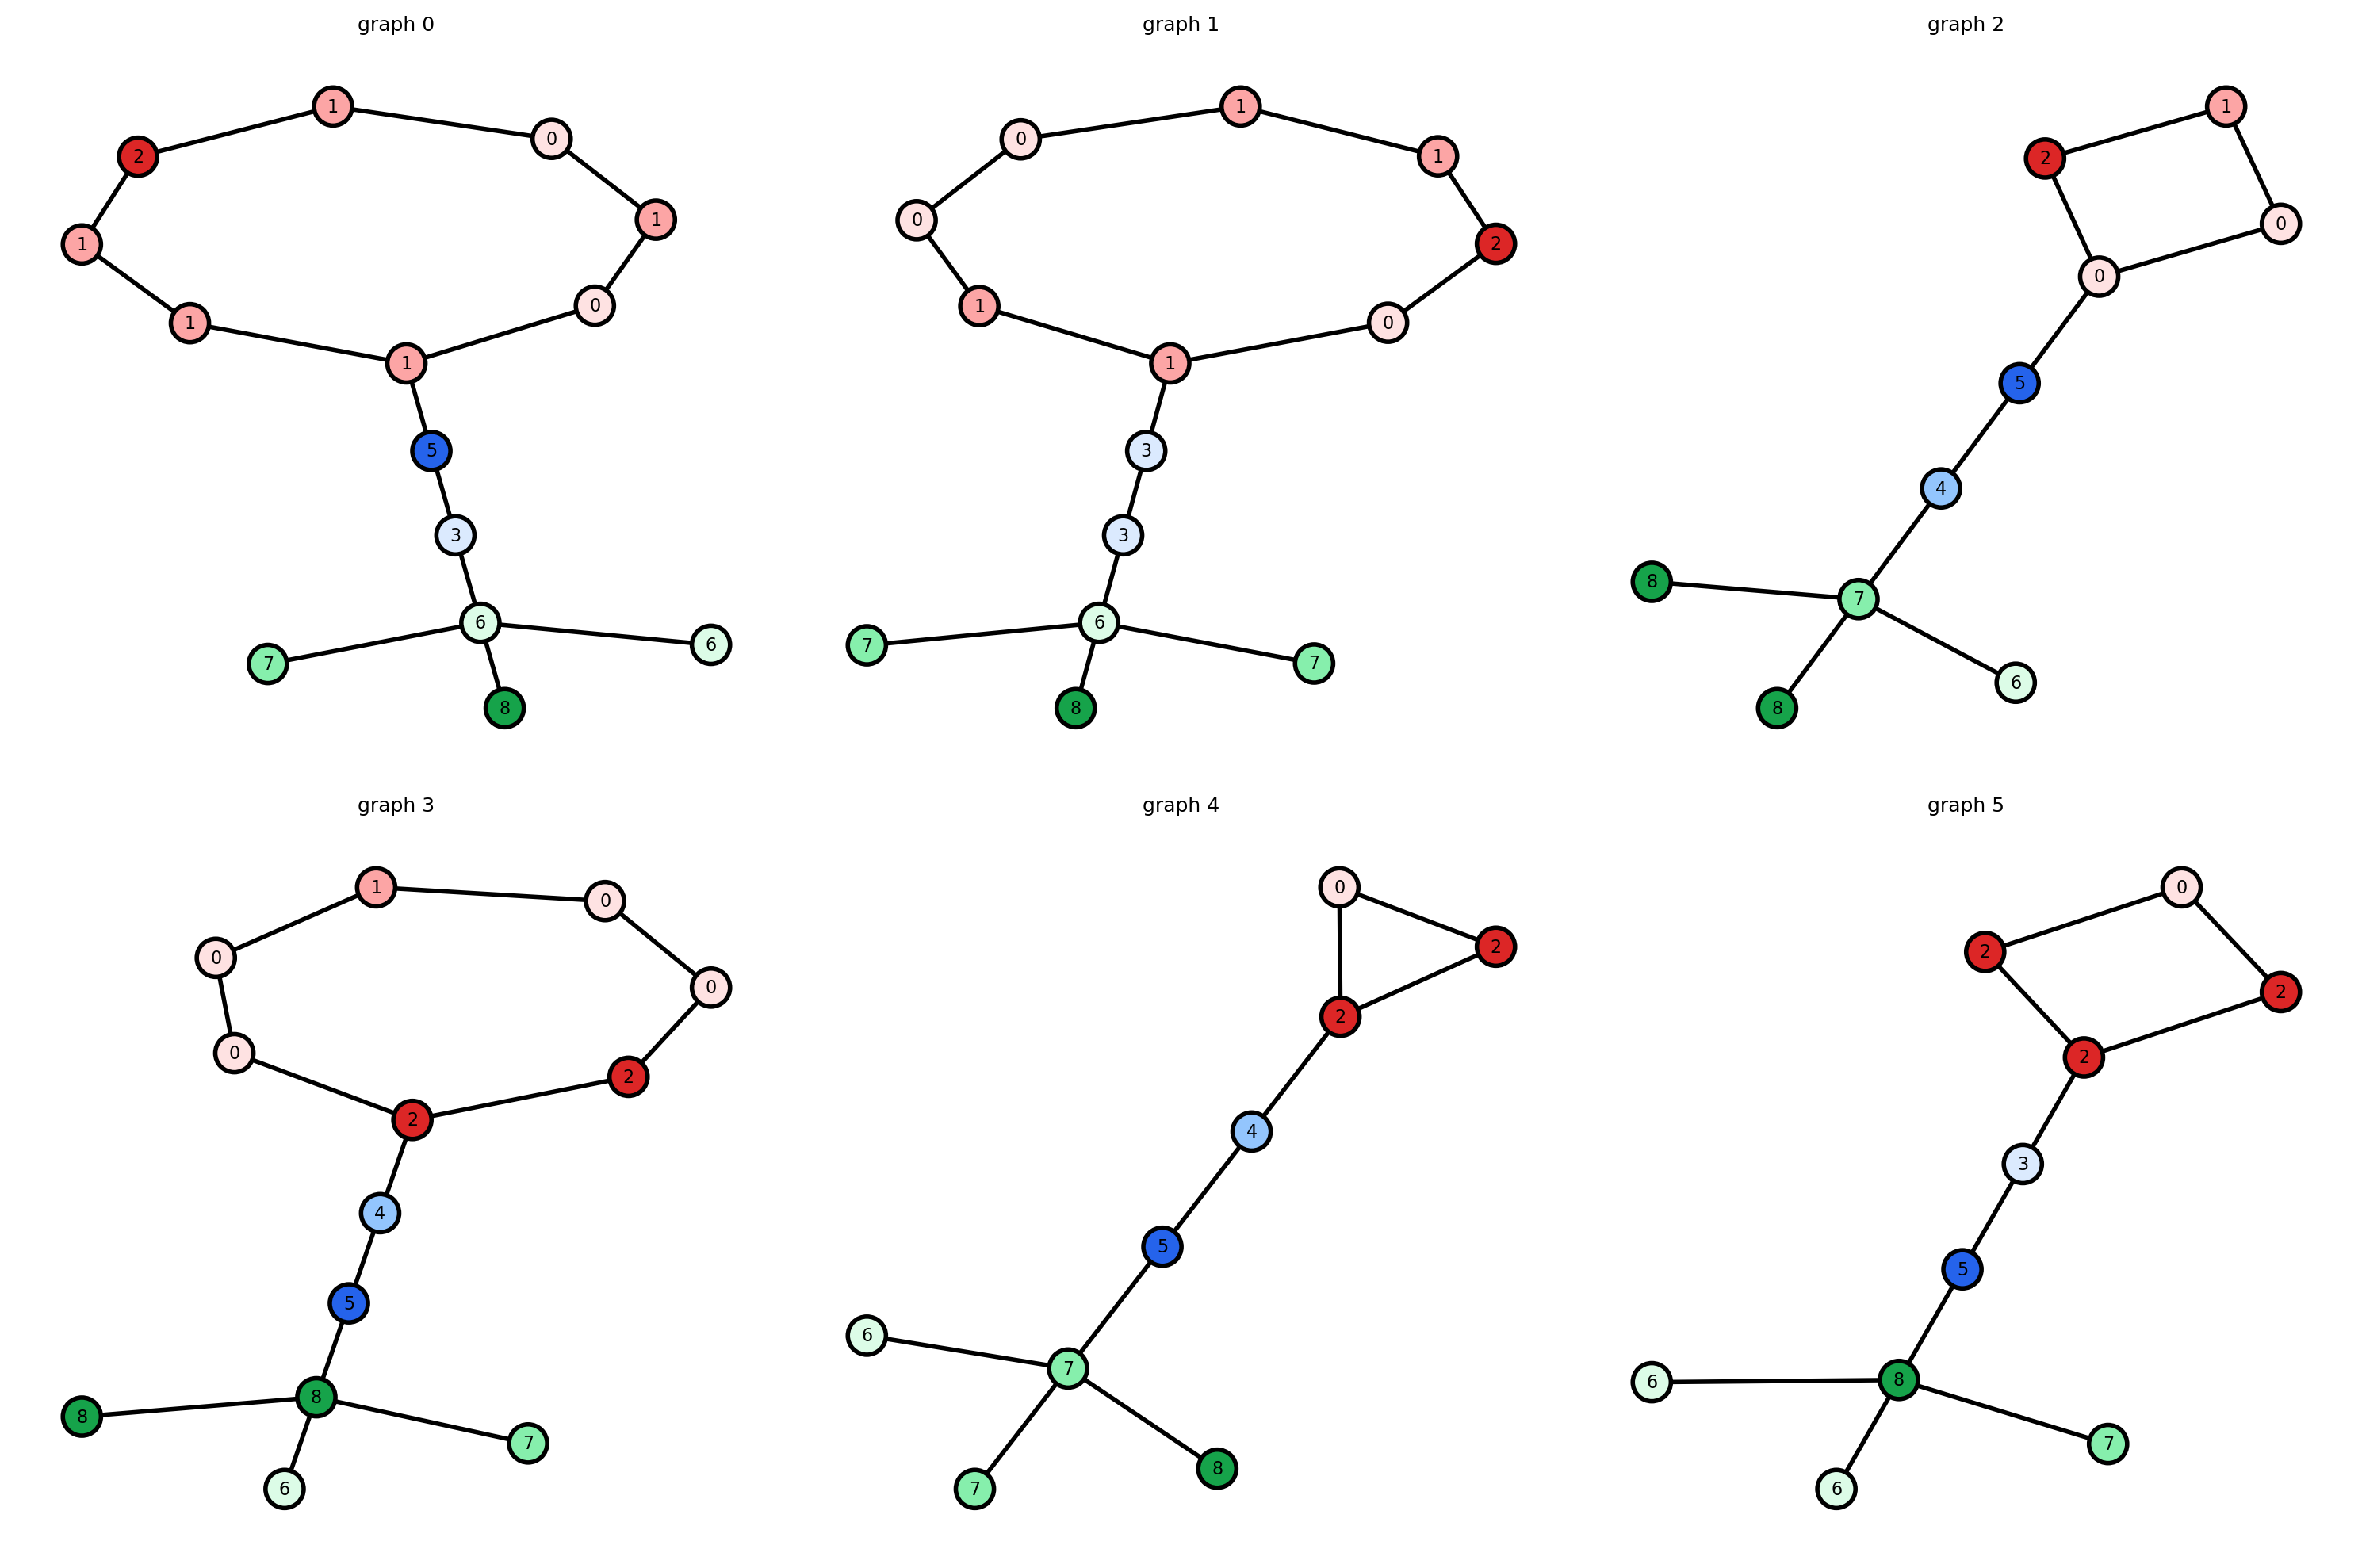

In [3]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    n_iterations=N_ITERATIONS,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

_ = plot_artificial_graphs(
    graphs[:6],
    n_cols=3,
    titles=[f'graph {idx}' for idx in range(6)],
    size=5,
)



In [4]:

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')

Configured graph generator model_name=artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350 model_dir=/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators
Training sample PDF: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/samples/artificial-cycle-path-star-n10000-c[3, 8]-p2-r3x1-d128-b128-e350/training_samples.pdf


In [ ]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=False,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=30,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350 model_dir=/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators
Fitting model on 10000 graphs
Fitting graph vectorizer on 10000 graphs
Finished fitting graph vectorizer on 10000 graphs in 0m 0.0s
Fitting node graph vectorizer on 10000 graphs
Finished fitting node graph vectorizer on 10000 graphs in 0m 0.0s
Encoding node embeddings for 10000 graphs
Finished encoding node embeddings for 10000 graphs in 3m 19.7s
Encoding graph embeddings for 10000 graphs
Finished encoding graph embeddings for 10000 graphs in 3m 47.8s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(114676, 2048), sparse=True, nnz=17348925, density=0.073870.
Prepared graph embedding matrix: shape=(10000, 2048), sparse=True, nnz=7797676, density=0.380746.
Sampled node embedding SVD fit rows: 114676 -> 10000.
Fitting node embedding SVD on shape=(10000, 2

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


epoch 1: completed epoch in 219.49s
epoch 2: completed epoch in 236.06s
epoch 3: completed epoch in 224.11s
epoch 4: completed epoch in 817.10s
epoch 5: completed epoch in 345.81s
epoch 6: completed epoch in 248.60s
epoch 7: completed epoch in 329.18s
epoch 8: completed epoch in 270.85s
epoch 9: completed epoch in 231.81s
Epoch 10/350 | ETA 23h 20m 01s:
  train total=   35.870 | node_field    24.042 [67.0%] |        deg   0.76964 [2.1%] |      exist   0.23262 [0.6%] | node_count   0.00511 [<0.1%]
  val   total=   33.906 | node_field    23.939 [70.6%] |        deg   0.66380 [2.0%] |      exist   0.23746 [0.7%] | node_count   0.00543 [<0.1%]
  train                 | node_label    1.3798 [3.8%] | edge_label   0.25877 [0.7%] |       edge    1.2734 [3.5%] | edge_count    7.3536 [20.5%] | deg_edge_consistency   0.00017 [<0.1%]
  val                   | node_label    1.1522 [3.4%] | edge_label   0.18713 [0.6%] |       edge    1.1568 [3.4%] | edge_count    6.0609 [17.9%] | deg_edge_consistenc

In [ ]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


In [ ]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=n_samples,
        apply_feasibility_filtering=True,
    )
    plot_artificial_graphs(
        filtered_samples,
        n_cols=n_samples,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
    )
